## A-3. Machine Learning with scikit-learn

### Goal

scikit-learnを使って、代表的な機械学習モデルを実装し、学習・予測・評価・比較を行う。

今回は以下のモデルを扱う。

* Logistic Regression
* SVM
* Random Forest
* k-means
* PCA


In [42]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import set_config
from sklearn.model_selection import train_test_split

set_config(display="text")

In [43]:
## Generate Data

np.random.seed(42)

N = 100

x_class0 = 2 * np.random.randn(N, 2) + np.array([-2, -2])
x_class1 = 2 * np.random.randn(N, 2) + np.array([2, 2])

X = np.vstack([x_class0, x_class1])

y = np.hstack([
    np.zeros(N),
    np.ones(N)
])

### 0. Train / Test Split

データを学習用とテスト用に分ける。

* Training data：モデルの学習に使用
* Test data：学習後の性能評価に使用

今回は80%を学習用、20%をテスト用とする。


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(160, 2) (40, 2) (160,) (40,)


### 1. LogisticRegression

前回のA2と同様の、分類問題である。

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 学習 (Training) を行い、モデルを構築する（パラメータを取得する）
model = LogisticRegression()
model.fit(X_train, y_train)
print("model.coef_:", model.coef_)
print("model.intercept_:", model.intercept_)

# Test用のデータに対して予測 (Prediction) ＆評価 (Evaluation) を行う
y_pred = model.predict(X_test)
print("y_pred:", y_pred)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy)


model.coef_: [[0.92269139 0.97929493]]
model.intercept_: [-0.20819952]
y_pred: [0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0.]
Accuracy = 0.95


### 2. Support Vector Machine

Support Vector Machine（SVM）は、2つのクラスを分離する決定境界を求めるモデルである。

SVMでは、各クラスのデータから決定境界までの距離（Margin）ができるだけ大きくなるように境界を決定する。

今回も二値分類を行い、Logistic Regressionと結果を比較する。


In [46]:
from sklearn.svm import SVC

model_svm = SVC(kernel="linear")
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)
print("y_pred_svm:", y_pred_svm)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy =", accuracy_svm)

y_pred_svm: [0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0.]
Accuracy = 0.95


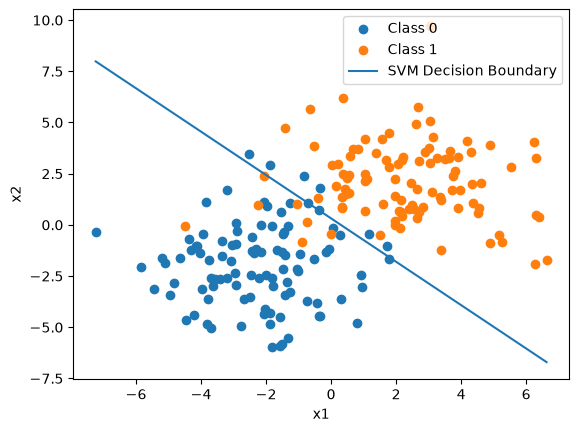

In [47]:
## 可視化

plt.scatter(
    x_class0[:, 0],
    x_class0[:, 1],
    label="Class 0"
)

plt.scatter(
    x_class1[:, 0],
    x_class1[:, 1],
    label="Class 1"
)

x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

w_svm = model_svm.coef_[0]
b_svm = model_svm.intercept_[0]

x2 = -(w_svm[0] * x1 + b_svm) / w_svm[1]

plt.plot(x1, x2, label="SVM Decision Boundary")

plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()